In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=sns.load_dataset('flights')
df

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121
...,...,...,...
139,1960,Aug,606
140,1960,Sep,508
141,1960,Oct,461
142,1960,Nov,390


In [4]:
#We get only year and month for the date, we need day also
#Convert the date to a YYYY-MM-DD format
df['yearMonth']="01-"+df['month'].astype(str)+"-"+df['year'].astype(str)
print(df.info())
df["yearMonth"]=pd.to_datetime("01-"+df["month"].astype(str)+"-"+df["year"].astype(str))
print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        144 non-null    int64   
 1   month       144 non-null    category
 2   passengers  144 non-null    int64   
 3   yearMonth   144 non-null    str     
dtypes: category(1), int64(2), str(1)
memory usage: 4.0 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   year        144 non-null    int64         
 1   month       144 non-null    category      
 2   passengers  144 non-null    int64         
 3   yearMonth   144 non-null    datetime64[us]
dtypes: category(1), datetime64[us](1), int64(2)
memory usage: 4.0 KB
None
   year month  passengers  yearMonth
0  1949   Jan         112 1949-01-01
1  1949   Feb         118 1949-02-01
2  1949   Mar         13

In [5]:
#Make yearMonth column as the dataframe index
df.set_index('yearMonth', inplace=True)
print(df.head())

            year month  passengers
yearMonth                         
1949-01-01  1949   Jan         112
1949-02-01  1949   Feb         118
1949-03-01  1949   Mar         132
1949-04-01  1949   Apr         129
1949-05-01  1949   May         121


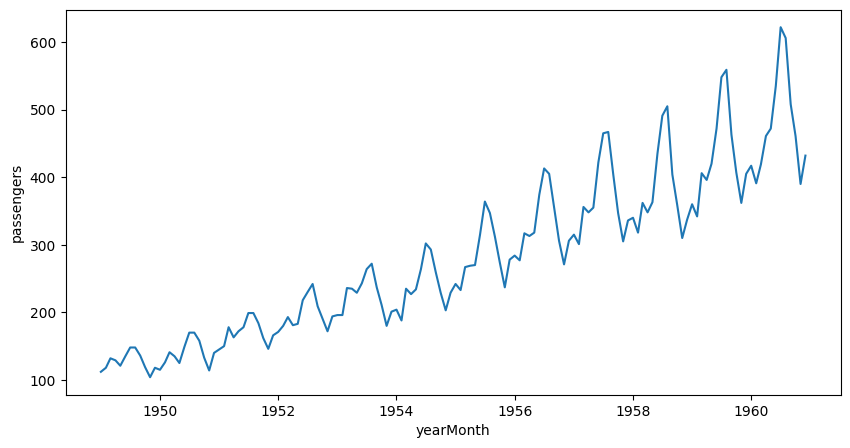

In [6]:
#Step:2 Visualize the time series
plt.figure(figsize=(10,5))
sns.lineplot(data=df,x=df.index,y=df.passengers)
plt.show()


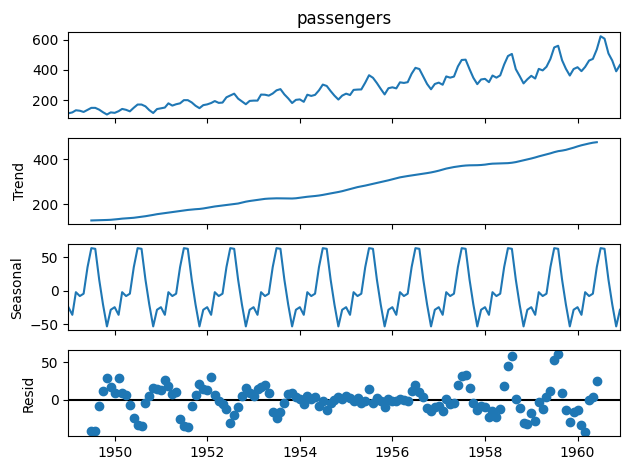

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition =seasonal_decompose(df.passengers, period=12)
fig=decomposition.plot()
plt.show()